In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

: 

In [ ]:
df = pd.read_csv('/workspaces/practice_final/data/raw/ems_2025_merged.csv')

In [ ]:
df = df[df['month'] == 1]

In [ ]:
df.head()

,incident_id,datetime,initial_type,initial_severity,final_type,final_severity,assignment_time,valid_dispatch_response,dispatch_response_sec,activation_time,...,datetime_hour,datetime_weather,temperture,precipitation,windspeed,weathercode,latitude_of_call,longitude_of_call,closest_station_name,closest_station_manhattan_miles
0,250010001,2025-01-01 00:00:12,STNDBY,8,STNDBY,8,2025-01-01T09:53:41.000,N,0,2025-01-01T09:57:09.000,...,2025-01-01 00:00:00,2025-01-01 00:00:00,46.8,0.0,10.7,3,40.5771,-73.9881,Engine 318/Ladder 166,0.300912
1,250010003,2025-01-01 00:01:53,UNC,2,UNC,2,2025-01-01T00:02:06.000,Y,13,2025-01-01T00:02:43.000,...,2025-01-01 00:00:00,2025-01-01 00:00:00,46.8,0.0,10.7,3,40.7506,-73.9971,Engine 34/Ladder 21,0.446225
2,250010004,2025-01-01 00:01:58,CARD,3,CARD,3,2025-01-01T00:01:58.000,Y,0,2025-01-01T00:01:58.000,...,2025-01-01 00:00:00,2025-01-01 00:00:00,46.8,0.0,10.7,3,40.7590,-73.9899,Battalion 9/Engine 54/Ladder 4,0.280244
3,250010007,2025-01-01 00:03:42,ABDPN,5,ABDPN,5,2025-01-01T00:03:59.000,Y,17,2025-01-01T00:04:12.000,...,2025-01-01 00:00:00,2025-01-01 00:00:00,46.8,0.0,10.7,3,40.8583,-73.9301,Engine 95/Ladder 36,0.712385
4,250010008,2025-01-01 00:04:36,STATEP,2,STATEP,2,2025-01-01T00:05:06.000,Y,30,2025-01-01T00:05:18.000,...,2025-01-01 00:00:00,2025-01-01 00:00:00,46.8,0.0,10.7,3,40.8899,-73.8466,Battalion 15/Engine 63/Ladder 39,0.668752


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 138016 entries, 0 to 138015
Data columns (total 51 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   incident_id                      138016 non-null  int64  
 1   datetime                         138016 non-null  object 
 2   initial_type                     138016 non-null  object 
 3   initial_severity                 138016 non-null  int64  
 4   final_type                       138016 non-null  object 
 5   final_severity                   138016 non-null  int64  
 6   assignment_time                  134783 non-null  object 
 7   valid_dispatch_response          138016 non-null  object 
 8   dispatch_response_sec            138016 non-null  int64  
 9   activation_time                  134537 non-null  object 
 10  on_scene_time                    129579 non-null  object 
 11  valid_incident_response          138016 non-null  object 
 12  travel_

In [ ]:
df.drop("incident_id", axis = 1).duplicated().sum()

np.int64(0)

In [ ]:
df.dropna(inplace=True)

In [ ]:
drop_list = ['incident_id', 'incident_response_sec', 'travel_time_sec', 'dispatch_response_sec', 
             'close_time', 'hospital_arrival_time', 'to_hospital_time', 'on_scene_time', 
             'activation_time', 'assignment_time', 'final_severity', 'final_type',
             # New drops for redundancy/low variance:
             'datetime', 'datetime_hour', 'datetime_weather', 'closest_station_name',
             'special_events', 'transferred', 'reopened', 'standby',  # Near-zero variance
             'precinct', 'council_district', 'community_district', 'school_district', 'congressional_district', # Redundant with borough,
             # changeable
             'zipcode', 'month', 'day', 'hour', 'temperture', 'precipitation', 'windspeed', 'latitude', 'longitude']

In [ ]:
df['incident_response_sec'].describe()

count    84962.000000
mean       862.570832
std       1122.937898
min          0.000000
25%        376.000000
50%        554.000000
75%        881.000000
max      28494.000000
Name: incident_response_sec, dtype: float64

<Axes: >

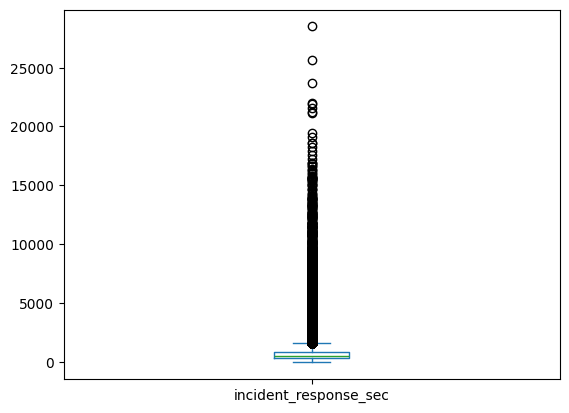

In [ ]:
df['incident_response_sec'].plot(kind='box')

In [ ]:
# Define bins and labels for the new categorical quality
bins = [0.0, 520.0, 700.0, 40000.0]  # Quality scores 0-520 (inclusive) -> Low, 520-700 -> Average, 700+ -> High
labels = ['low', 'average', 'high']

# Apply pd.cut to create the new categorical 'quality' column
y_categorical = pd.cut(df['incident_response_sec'].notna(), bins=bins, labels=labels, right=True)

In [ ]:
X = df.drop(drop_list, axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size = 0.2, random_state = 42)
X_train.head()

,initial_type,initial_severity,valid_dispatch_response,valid_incident_response,held,disposition,borough,dispatch_area,year,week_day,is_weekend,is_rush_hour,time_of_day,season,is_holiday,weathercode,latitude_of_call,longitude_of_call,closest_station_manhattan_miles
15050,DIFFBR,2,Y,Y,N,82,BROOKLYN,K2,2025,Saturday,1,0,morning,winter,0,1,40.6216,-74.0302,0.325919
105795,CARDBR,2,Y,Y,N,82,QUEENS,Q2,2025,Friday,0,1,afternoon,winter,0,0,40.6977,-73.7869,0.594624
54133,ABDPN,5,Y,Y,N,82,BRONX,B1,2025,Monday,0,1,morning,winter,0,1,40.8056,-73.9183,0.143343
22734,ABDPN,5,Y,Y,N,82,BROOKLYN,K7,2025,Monday,0,1,morning,winter,0,3,40.7018,-73.9424,0.523210
118492,SICK,6,Y,Y,Y,82,MANHATTAN,M3,2025,Monday,0,1,afternoon,winter,0,0,40.7655,-73.9879,0.387384


In [ ]:
X_train.shape

(67969, 19)

In [ ]:
# Examine X_train columns and data types
print("X_train columns:")
print(X_train.columns.tolist())
print("\nData types:")
print(X_train.dtypes)
print("\nNumeric columns:")
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
print(numeric_cols)
print("\nCategorical columns:")
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

X_train columns:
['initial_type', 'initial_severity', 'valid_dispatch_response', 'valid_incident_response', 'held', 'disposition', 'borough', 'dispatch_area', 'year', 'week_day', 'is_weekend', 'is_rush_hour', 'time_of_day', 'season', 'is_holiday', 'weathercode', 'latitude_of_call', 'longitude_of_call', 'closest_station_manhattan_miles']

Data types:
initial_type                        object
initial_severity                     int64
valid_dispatch_response             object
valid_incident_response             object
held                                object
disposition                         object
borough                             object
dispatch_area                       object
year                                 int64
week_day                            object
is_weekend                           int64
is_rush_hour                         int64
time_of_day                         object
season                              object
is_holiday                           int64
wea

In [ ]:
# Check cardinality (unique values) and variance
print("=" * 70)
print("CARDINALITY ANALYSIS (number of unique values)")
print("=" * 70)
cardinality = X_train.nunique().sort_values(ascending=False)
print(cardinality)

print("\n" + "=" * 70)
print("VARIANCE AND VALUE DISTRIBUTION FOR LOW-FREQUENCY FEATURES")
print("=" * 70)
for col in ['reopened', 'special_events', 'standby', 'transferred', 'held', 
            'valid_dispatch_response', 'valid_incident_response']:
    if col in X_train.columns:
        print(f"\n{col}:")
        print(X_train[col].value_counts())
        print(f"  Dominant value percentage: {X_train[col].value_counts(normalize=True).iloc[0]*100:.1f}%")

CARDINALITY ANALYSIS (number of unique values)
closest_station_manhattan_miles    184
longitude_of_call                  180
latitude_of_call                   177
initial_type                        75
dispatch_area                       31
weathercode                         12
initial_severity                     8
disposition                          8
week_day                             7
borough                              5
time_of_day                          4
is_holiday                           2
is_rush_hour                         2
held                                 2
is_weekend                           2
valid_dispatch_response              1
valid_incident_response              1
year                                 1
season                               1
dtype: int64

VARIANCE AND VALUE DISTRIBUTION FOR LOW-FREQUENCY FEATURES

held:
held
N    55820
Y    12149
Name: count, dtype: int64
  Dominant value percentage: 82.1%

valid_dispatch_response:
valid_dispatch_res

In [ ]:
X_train.isna().sum().sum()

np.int64(0)

In [ ]:
X_train.describe()

,initial_severity,year,is_weekend,is_rush_hour,is_holiday,weathercode,latitude_of_call,longitude_of_call,closest_station_manhattan_miles
count,67969.000000,67969.0,67969.000000,67969.000000,67969.000000,67969.000000,67969.000000,67969.000000,67969.000000
mean,4.024423,2025.0,0.245965,0.321897,0.062823,6.230267,40.737181,-73.920588,0.483911
std,1.705935,0.0,0.430661,0.467207,0.242646,16.649580,0.086056,0.079413,0.276231
min,1.000000,2025.0,0.000000,0.000000,0.000000,0.000000,40.507000,-74.242600,0.076895
25%,2.000000,2025.0,0.000000,0.000000,0.000000,0.000000,40.670900,-73.965500,0.290274
50%,4.000000,2025.0,0.000000,0.000000,0.000000,2.000000,40.734100,-73.920000,0.423131
75%,5.000000,2025.0,0.000000,1.000000,0.000000,3.000000,40.818100,-73.873600,0.635447
max,8.000000,2025.0,1.000000,1.000000,1.000000,75.000000,40.898500,-73.711600,2.005654


In [ ]:
y_train.describe()

count     67969
unique        1
top         low
freq      67969
Name: incident_response_sec, dtype: object

## Feature Selection

In [ ]:
X_train.dropna(inplace=True)

In [ ]:
X_train_dummies = pd.get_dummies(X_train, drop_first=True)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
#instantiate a linear regression model
linreg_model = LinearRegression()

In [ ]:
X_train_dummies.isna().sum()

initial_severity       0
year                   0
is_weekend             0
is_rush_hour           0
is_holiday             0
                      ..
week_day_Tuesday       0
week_day_Wednesday     0
time_of_day_evening    0
time_of_day_morning    0
time_of_day_night      0
Length: 134, dtype: int64

In [ ]:
#fit the model to our training data
linreg_model.fit(X_train_dummies.notnull(), y_train)


ValueError: could not convert string to float: 'low'

In [ ]:
#make our first set of predictions (again on the training data)
train_preds = linreg_model.predict(X_train_dummies)

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [ ]:
print(f"Root mean squared error (RMSE): {root_mean_squared_error(y_true = y_train, y_pred=train_preds)}")
print(f"Mean absolute error (MAE): {mean_absolute_error(y_true = y_train, y_pred=train_preds)}")
print(f"R^2 score: {r2_score(y_true = y_train, y_pred=train_preds)}")

Root mean squared error (RMSE): 568.9699645139574
Mean absolute error (MAE): 300.2894134574344
R^2 score: 0.31113550316042304


Initial r^2 score: .311

Text(0, 0.5, 'Predicted values')

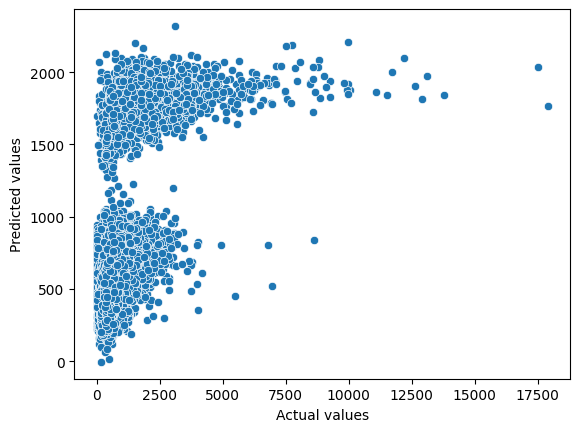

In [ ]:
sns.scatterplot(x = y_train, y=train_preds)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")

In order to improve our accuracy I will first engineer our target response time into buckets (low,average,high)

NameError: name 'ddd' is not defined